# Logistic regression tutorial

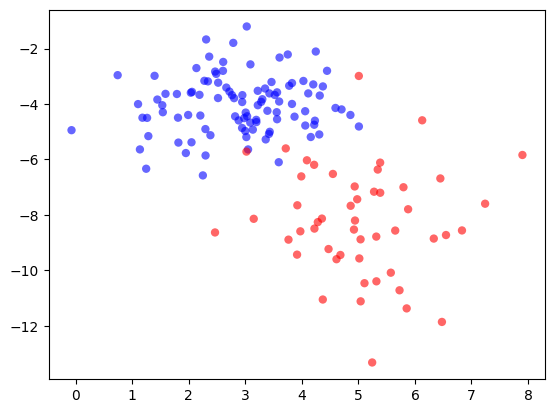

In [1]:
import numpy as np
import matplotlib.pyplot as plt

size_1 = 100
size_2 = 50

np.random.seed(44)

xs = np.concat(
    [np.random.randn(size_1) + 3, np.random.randn(size_2) + 5]
)

ys = np.concat(
    [np.random.randn(size_1) - 4, np.random.randn(size_2)*2 - 8]
)

zs = np.concat(
    [[0] * size_1, [1] * size_2]
)

plt.scatter(xs, ys, c=zs, cmap='bwr', alpha=0.6, edgecolors='none')

w = -8.5
b = 45

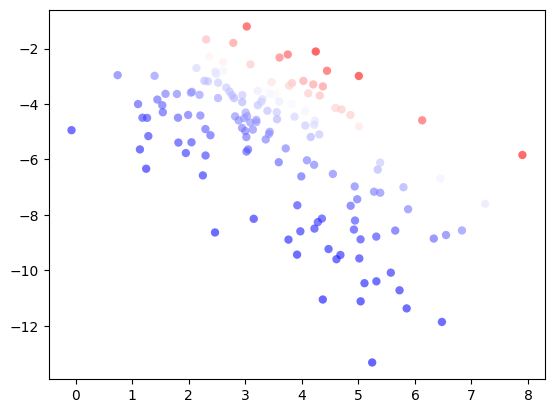

In [2]:
def sigmoid(wx, xs, wy, ys, b):
    return 1 / (1 + np.exp(-wx*xs-wy*ys-b))

wx = 0.5
wy = 0.5
b = -1
zhats = sigmoid(wx, xs, wy, ys, b)

plt.scatter(xs, ys, c=zhats, cmap='bwr', alpha=0.6, edgecolors='none')

In [3]:
zs * np.log(zhats)

array([-0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.        ,
       -0.        , -0.        , -0.        , -0.        , -0.  

In [4]:
(1 - zs) * np.log(1 - zhats)

array([-0.04144829, -0.4066749 , -0.72840191, -0.15378339, -0.09964153,
       -0.05170065, -0.38099471, -0.15422106, -0.22718097, -0.2264127 ,
       -0.15612552, -0.15120621, -0.05977432, -0.52947772, -0.06721009,
       -0.13203422, -0.22892307, -0.14532938, -0.40006243, -0.13623458,
       -0.09180501, -0.27458456, -0.47242541, -0.12428215, -0.17824759,
       -0.45697635, -0.09510434, -0.64931434, -0.33055386, -0.16947421,
       -0.301164  , -0.09984566, -0.29321974, -0.29076413, -0.28845715,
       -0.16349121, -0.26007075, -0.02949412, -0.28744177, -0.11493154,
       -0.06020129, -0.07035326, -0.58397715, -0.0380175 , -0.14875586,
       -0.20922201, -0.15514239, -0.2425115 , -0.34089074, -0.47515726,
       -0.28716334, -0.60774482, -0.09602659, -0.38993168, -0.22930714,
       -0.24896782, -0.38611653, -0.15819594, -0.12844772, -0.32276931,
       -0.3792236 , -0.11696024, -0.31082568, -0.2025184 , -0.34944942,
       -0.0678209 , -0.13996049, -0.08926381, -0.221428  , -0.37

Interesting. Is this why we need to sum cross entropies of classes?

In [5]:
def cross_entropy(zs, zhats):
    return np.sum(zs * np.log(zhats) + (1 - zs) * np.log(1 - zhats))

cross_entropy(zs, zhats)

np.float64(-159.0465129546982)

Now let's MANUALLY adjust the parameters, in a mazochistic way.

Cross-entropy = -1405.8012673184603


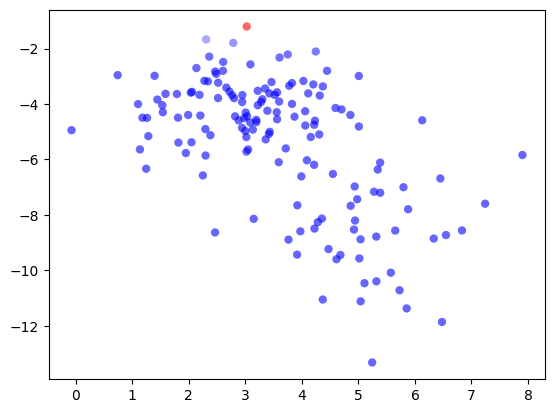

In [6]:
wx = 0.1
wy = 3.1
b = -3.1
zhats = sigmoid(wx, xs, wy, ys, b)
ce = cross_entropy(zs, zhats)

plt.scatter(xs, ys, c=zhats, cmap='bwr', alpha=0.6, edgecolors='none')
print("Cross-entropy =", ce)


This is very cool, but can we automate that? The answer is yes. We can use Maximum Likelihood Estimation, either via Newton-Raphson method or Gradient Ascent.

$$
\theta = \theta + \alpha \nabla L(\theta)
$$

Let's start by hand-crafting the gradient function.

In [7]:
def grad2(f, wx, wy, b, eps = 1e-8):
    "Gradient of 3-parameter function"
    two_eps = 2 * eps
    return np.array([
        f(wx + eps, wy, b) - f(wx - eps, wy, b),
        f(wx, wy + eps, b) - f(wx, wy - eps, b),
        f(wx, wy, b + eps) - f(wx, wy, b - eps),
    ]) / two_eps

alpha = 0.001

alpha * grad2(
    f=lambda wx, wy, b: cross_entropy(zs, sigmoid(wx, xs, wy, ys, b)),
    wx=0,
    wy=0,
    b=0
)

array([-0.0198802 , -0.00420065, -0.025     ])

0.10353434014120921 -0.09539022429549959 0.06190042674276697 -125.28183268459031


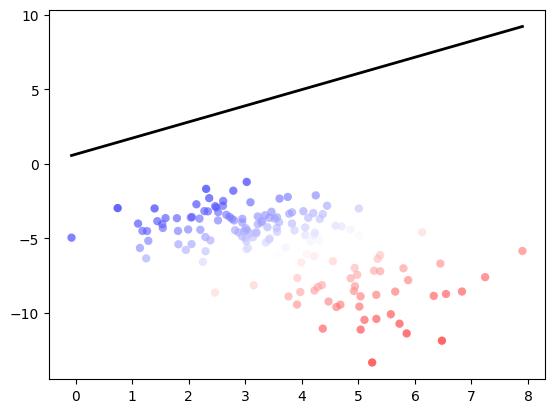

In [8]:
wx = 0
wy = 0
b = 0
alpha = 0.000009

for i in range(200):
    [wx, wy, b] = np.array([wx, wy, b]) - alpha * grad2(
        f=lambda wx, wy, b: cross_entropy(zs, sigmoid(wx, xs, wy, ys, b)),
        wx=wx,
        wy=wy,
        b=b
    )
zhats = sigmoid(wx, xs, wy, ys, b)
print(wx, wy, b, cross_entropy(zs, sigmoid(wx, xs, wy, ys, b)))
plt.scatter(xs, ys, c=zhats, cmap='bwr', alpha=0.6, edgecolors='none')

x_line = np.linspace(xs.min(), xs.max(), 100)

if abs(wy) > 1e-9:
    y_line = (-wx * x_line - b) / wy
else:
    y_line = np.linspace(ys.min(), ys.max(), 100)
    x_line = np.full_like(y_line, -b / wx)

# Decision boundary
plt.plot(x_line, y_line, 'k-', linewidth=2, label='Decision Boundary')